# DBSCAN Clustering with Evaluation Metrics

This notebook demonstrates how to:
1. Generate synthetic data for clustering
2. Apply DBSCAN clustering algorithm
3. Evaluate clustering performance using three metrics:
   - Silhouette Score
   - Calinski-Harabasz Index
   - Davies-Bouldin Index
4. Visualize the clustering results and find the optimal parameters for DBSCAN

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 1. Generate Synthetic Data

We'll create a synthetic dataset with a known number of clusters to demonstrate DBSCAN clustering.

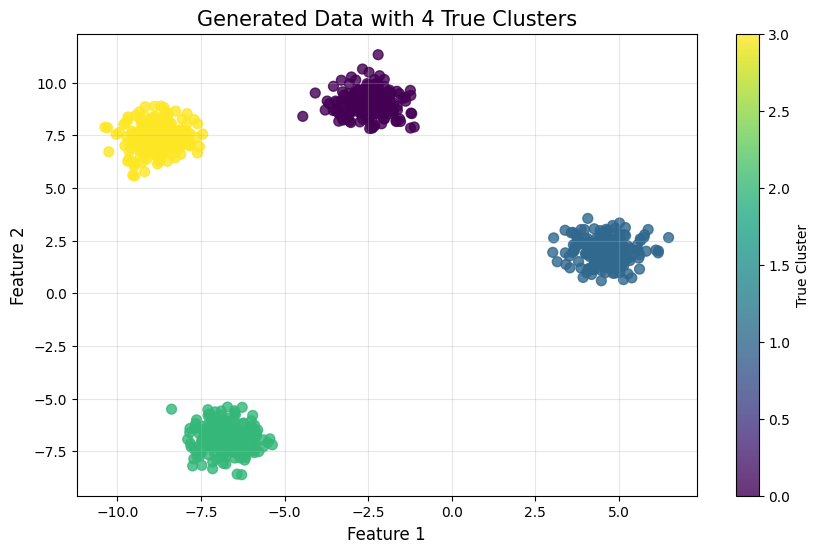

In [2]:
# Generate synthetic data with 4 true clusters
X, y_true = make_blobs(n_samples=800, centers=4, cluster_std=0.60, random_state=42)

# Plot the generated data
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.8, s=50)
plt.title('Generated Data with 4 True Clusters', fontsize=15)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.colorbar(label='True Cluster')
plt.grid(alpha=0.3)
plt.show()

## 2. Finding Optimal DBSCAN Parameters

Unlike K-means where we specify the number of clusters, DBSCAN requires two parameters:
- `eps`: The maximum distance between two samples for one to be considered in the neighborhood of the other
- `min_samples`: The minimum number of samples in a neighborhood for a point to be considered a core point

Let's use the k-distance graph to find a good `eps` value:

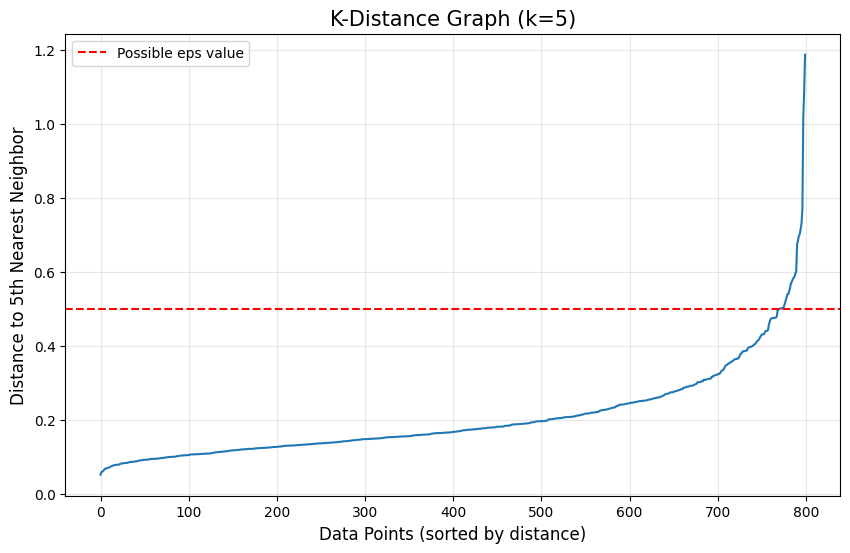

In [3]:
# Function to plot k-distance graph
def plot_k_distance_graph(X, k=5):
    # Calculate distances to k nearest neighbors
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, indices = neigh.kneighbors(X)
    
    # Sort distances in ascending order
    distances = np.sort(distances[:, k-1])
    
    # Plot k-distance graph
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.title(f'K-Distance Graph (k={k})', fontsize=15)
    plt.xlabel('Data Points (sorted by distance)', fontsize=12)
    plt.ylabel(f'Distance to {k}th Nearest Neighbor', fontsize=12)
    plt.grid(alpha=0.3)
    
    # Look for the "elbow" in the plot
    plt.axhline(y=0.5, color='r', linestyle='--', label='Possible eps value')
    plt.legend()
    plt.show()
    
    return distances

# Plot k-distance graph
k_distances = plot_k_distance_graph(X, k=5)

## 3. Apply DBSCAN Clustering

Now, let's apply DBSCAN with different parameter values and evaluate the results:

In [4]:
# Function to perform DBSCAN clustering and evaluate metrics
def perform_dbscan(X, eps, min_samples):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    clusters = dbscan.fit_predict(X)
    
    # Count number of clusters (excluding noise points with label -1)
    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    n_noise = list(clusters).count(-1)
    
    # Calculate evaluation metrics only if more than one cluster is found
    if n_clusters > 1:
        # Create a mask for non-noise points
        mask = clusters != -1
        if sum(mask) > 1:  # Need at least 2 non-noise points for metrics
            silhouette = silhouette_score(X[mask], clusters[mask])
            calinski = calinski_harabasz_score(X[mask], clusters[mask])
            davies = davies_bouldin_score(X[mask], clusters[mask])
        else:
            silhouette, calinski, davies = np.nan, np.nan, np.nan
    else:
        silhouette, calinski, davies = np.nan, np.nan, np.nan
    
    return clusters, silhouette, calinski, davies, n_clusters, n_noise

In [5]:
# Try different parameter values
eps_range = np.arange(0.3, 0.9, 0.1)
min_samples_range = [3, 5, 10, 15, 20]
results = []

for eps in eps_range:
    for min_samples in min_samples_range:
        clusters, silhouette, calinski, davies, n_clusters, n_noise = perform_dbscan(X, eps, min_samples)
        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': silhouette,
            'calinski_harabasz': calinski,
            'davies_bouldin': davies
        })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.dropna()
results_df

,eps,min_samples,n_clusters,n_noise,silhouette,calinski_harabasz,davies_bouldin
0,0.3,3,8,31,0.398569,11889.905570,0.593841
1,0.3,5,5,62,0.713884,21071.446789,0.377230
2,0.3,10,4,174,0.901643,31865.830183,0.140324
3,0.3,15,5,261,0.749359,26648.562701,0.365516
4,0.3,20,4,396,0.926534,36301.131387,0.105673
5,0.4,3,5,18,0.769590,19621.862823,0.289322
6,0.4,5,4,24,0.879929,26207.590102,0.169490
7,0.4,10,4,64,0.886268,27899.029450,0.161503
8,0.4,15,4,102,0.892282,29555.474962,0.153470
9,0.4,20,4,154,0.898642,31369.047517,0.144799


## 4. Evaluate Clustering Performance

Let's understand what each evaluation metric means:

1. **Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters. Range from -1 to 1, where higher values indicate better clustering.

2. **Calinski-Harabasz Index**: Ratio of between-cluster variance to within-cluster variance. Higher values indicate better defined clusters.

3. **Davies-Bouldin Index**: Average similarity between each cluster and its most similar cluster. Lower values indicate better clustering.

Now, let's visualize these metrics for different DBSCAN parameters to find the optimal values.

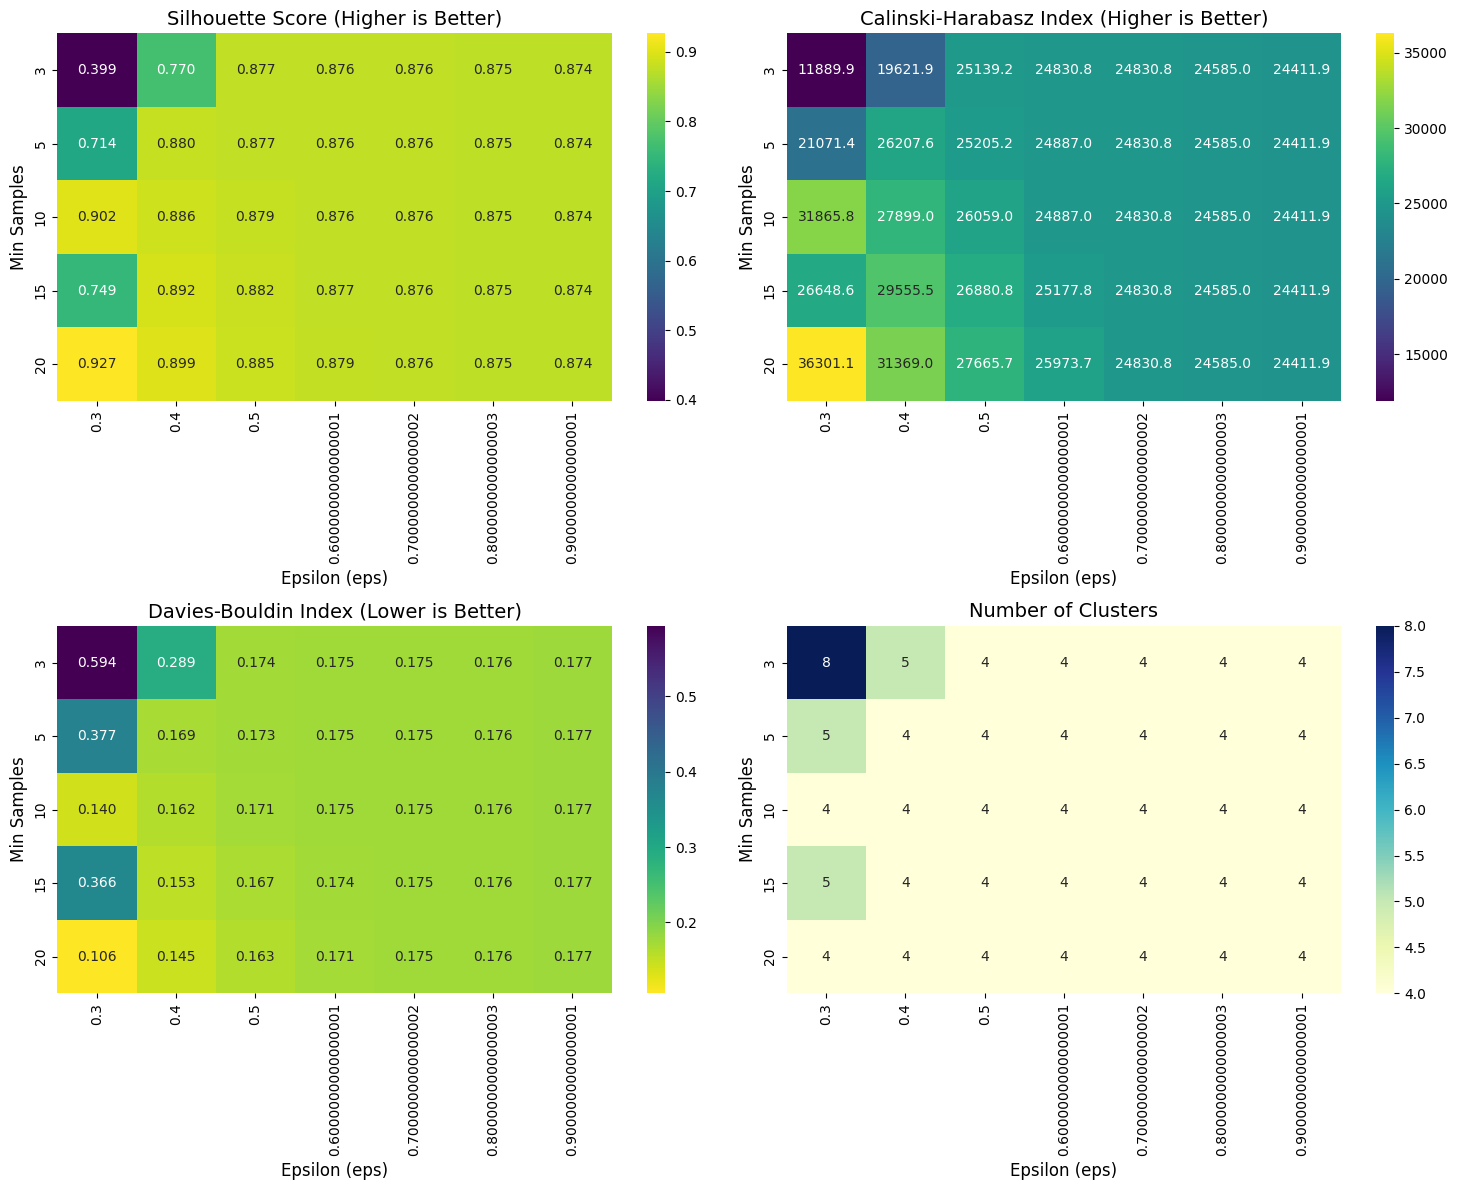

In [6]:
# Create a 2x2 grid for our evaluation metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Create a pivot table for each metric
silhouette_pivot = results_df.pivot_table(index='min_samples', columns='eps', values='silhouette')
calinski_pivot = results_df.pivot_table(index='min_samples', columns='eps', values='calinski_harabasz')
davies_pivot = results_df.pivot_table(index='min_samples', columns='eps', values='davies_bouldin')
clusters_pivot = results_df.pivot_table(index='min_samples', columns='eps', values='n_clusters')

# Silhouette Score (higher is better)
sns.heatmap(silhouette_pivot, annot=True, cmap='viridis', ax=axes[0, 0], fmt='.3f')
axes[0, 0].set_title('Silhouette Score (Higher is Better)', fontsize=14)
axes[0, 0].set_xlabel('Epsilon (eps)', fontsize=12)
axes[0, 0].set_ylabel('Min Samples', fontsize=12)

# Calinski-Harabasz Index (higher is better)
sns.heatmap(calinski_pivot, annot=True, cmap='viridis', ax=axes[0, 1], fmt='.1f')
axes[0, 1].set_title('Calinski-Harabasz Index (Higher is Better)', fontsize=14)
axes[0, 1].set_xlabel('Epsilon (eps)', fontsize=12)
axes[0, 1].set_ylabel('Min Samples', fontsize=12)

# Davies-Bouldin Index (lower is better)
sns.heatmap(davies_pivot, annot=True, cmap='viridis_r', ax=axes[1, 0], fmt='.3f')
axes[1, 0].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=14)
axes[1, 0].set_xlabel('Epsilon (eps)', fontsize=12)
axes[1, 0].set_ylabel('Min Samples', fontsize=12)

# Number of clusters
sns.heatmap(clusters_pivot, annot=True, cmap='YlGnBu', ax=axes[1, 1], fmt='d')
axes[1, 1].set_title('Number of Clusters', fontsize=14)
axes[1, 1].set_xlabel('Epsilon (eps)', fontsize=12)
axes[1, 1].set_ylabel('Min Samples', fontsize=12)

plt.tight_layout()
plt.show()

## 5. Find Optimal Parameters

Based on the evaluation metrics, let's identify the best parameters for DBSCAN.

In [7]:
# Find the best parameters for each metric
best_silhouette = results_df.loc[results_df['silhouette'].idxmax()]
best_calinski = results_df.loc[results_df['calinski_harabasz'].idxmax()]
best_davies = results_df.loc[results_df['davies_bouldin'].idxmin()]

print("Optimal parameters based on Silhouette Score:")
print(f"eps: {best_silhouette['eps']}, min_samples: {best_silhouette['min_samples']}")
print(f"Number of clusters: {best_silhouette['n_clusters']}")
print(f"Silhouette Score: {best_silhouette['silhouette']:.4f}")
print()

print("Optimal parameters based on Calinski-Harabasz Index:")
print(f"eps: {best_calinski['eps']}, min_samples: {best_calinski['min_samples']}")
print(f"Number of clusters: {best_calinski['n_clusters']}")
print(f"Calinski-Harabasz Index: {best_calinski['calinski_harabasz']:.4f}")
print()

print("Optimal parameters based on Davies-Bouldin Index:")
print(f"eps: {best_davies['eps']}, min_samples: {best_davies['min_samples']}")
print(f"Number of clusters: {best_davies['n_clusters']}")
print(f"Davies-Bouldin Index: {best_davies['davies_bouldin']:.4f}")

Optimal parameters based on Silhouette Score:
eps: 0.3, min_samples: 20.0
Number of clusters: 4.0
Silhouette Score: 0.9265

Optimal parameters based on Calinski-Harabasz Index:
eps: 0.3, min_samples: 20.0
Number of clusters: 4.0
Calinski-Harabasz Index: 36301.1314

Optimal parameters based on Davies-Bouldin Index:
eps: 0.3, min_samples: 20.0
Number of clusters: 4.0
Davies-Bouldin Index: 0.1057


## 6. Visualize the Clustering Results

Now, let's visualize the clustering results using the optimal parameters.

In [8]:
# Determine the most frequently suggested optimal parameter set
optimal_suggestions = [
    (best_silhouette['eps'], best_silhouette['min_samples']),
    (best_calinski['eps'], best_calinski['min_samples']),
    (best_davies['eps'], best_davies['min_samples'])
]
from collections import Counter
counter = Counter(optimal_suggestions)
optimal_params = counter.most_common(1)[0][0]
optimal_eps, optimal_min_samples = optimal_params

print(f"Based on majority voting, the optimal parameters are: eps={optimal_eps}, min_samples={optimal_min_samples}")

Based on majority voting, the optimal parameters are: eps=0.3, min_samples=20.0


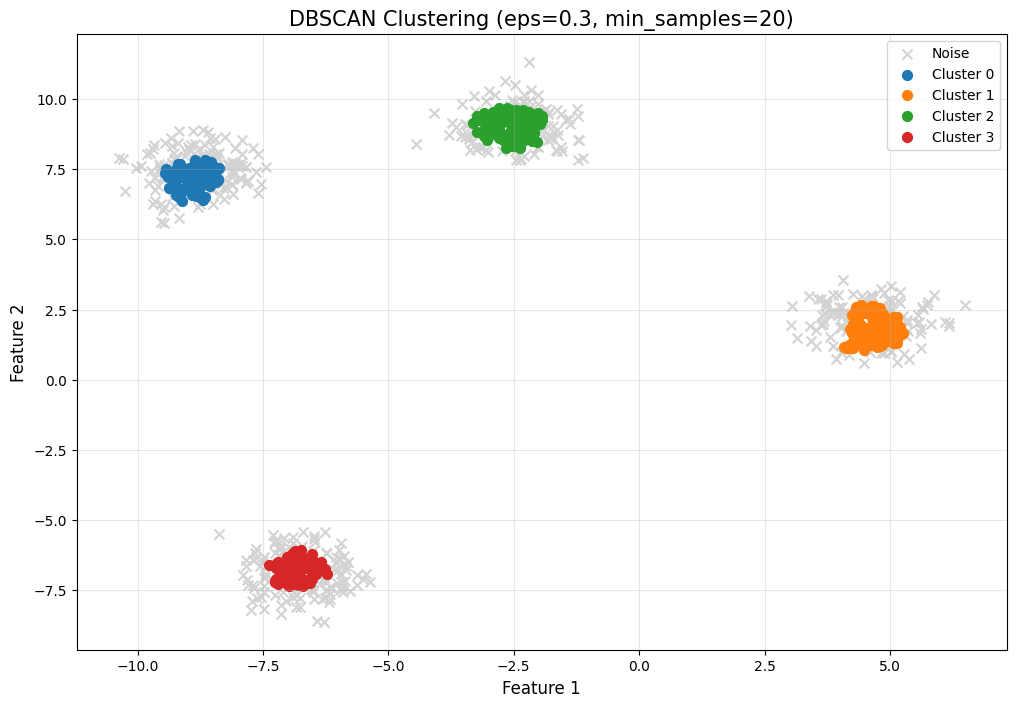

Number of clusters: 4
Number of noise points: 396 (49.50%)


In [9]:
# Perform DBSCAN with the optimal parameters
dbscan = DBSCAN(eps=optimal_eps, min_samples=int(optimal_min_samples))
cluster_labels = dbscan.fit_predict(X)

# Count clusters and noise points
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

# Plot the clusters
plt.figure(figsize=(12, 8))

# Plot noise points in gray
plt.scatter(X[cluster_labels == -1, 0], X[cluster_labels == -1, 1], 
            color='lightgray', marker='x', s=50, label='Noise')

# Plot the clusters with different colors
for i in range(n_clusters):
    plt.scatter(X[cluster_labels == i, 0], X[cluster_labels == i, 1], 
                s=50, label=f'Cluster {i}')

plt.title(f'DBSCAN Clustering (eps={optimal_eps}, min_samples={int(optimal_min_samples)})', fontsize=15)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise} ({n_noise / len(X) * 100:.2f}%)")

## 7. Create a More Complex Dataset

Let's create a more complex dataset to test our clustering approach.

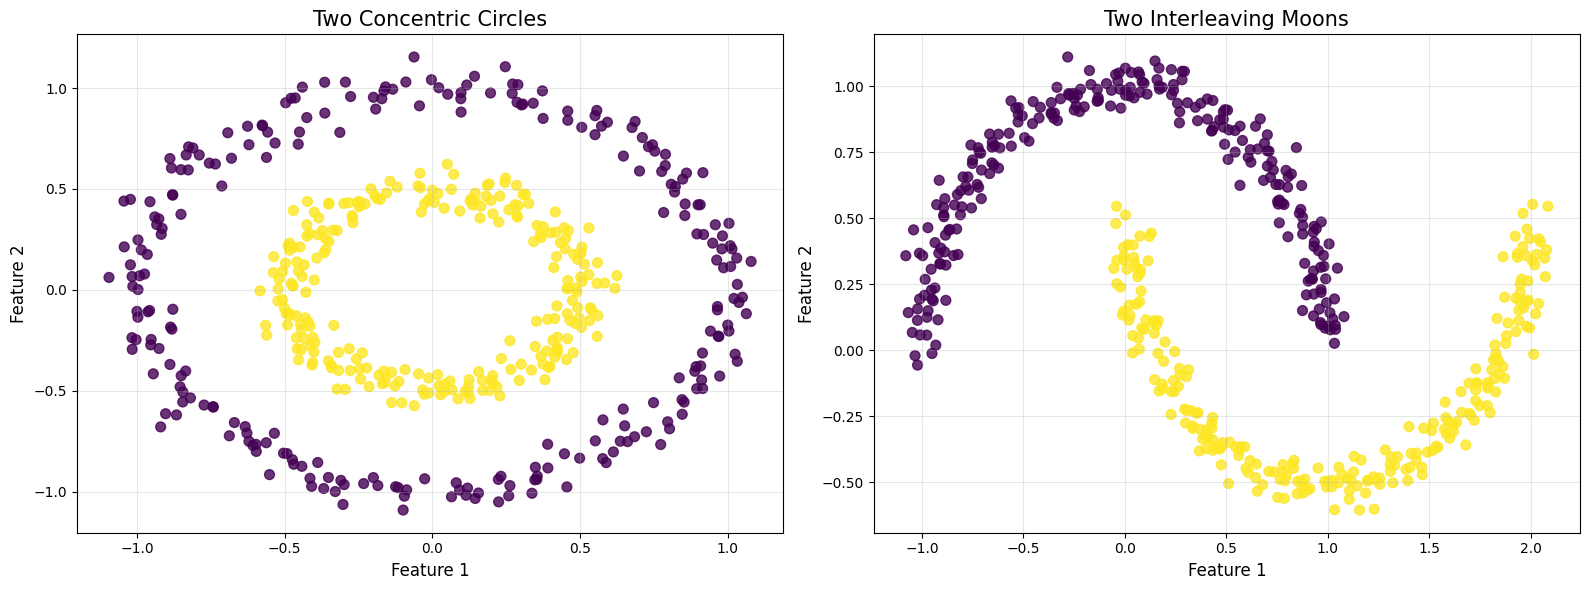

In [10]:
# Generate a more complex dataset
from sklearn.datasets import make_moons, make_circles

# Generate two interleaving half circles
X_circles, y_circles = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)

# Generate two interleaving moons
X_moons, y_moons = make_moons(n_samples=500, noise=0.05, random_state=42)

# Plot the complex datasets
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='viridis', alpha=0.8, s=50)
axes[0].set_title('Two Concentric Circles', fontsize=15)
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)
axes[0].grid(alpha=0.3)

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', alpha=0.8, s=50)
axes[1].set_title('Two Interleaving Moons', fontsize=15)
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Evaluate DBSCAN on Complex Datasets

Let's apply DBSCAN to these more complex datasets and evaluate the results.

In [11]:
# Function to evaluate DBSCAN on a dataset
def evaluate_dbscan_on_dataset(X, true_labels, title, eps=0.2, min_samples=5):
    # Apply DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    predicted_labels = dbscan.fit_predict(X)
    
    # Count clusters and noise points
    n_clusters = len(set(predicted_labels)) - (1 if -1 in predicted_labels else 0)
    n_noise = list(predicted_labels).count(-1)
    
    # Calculate evaluation metrics (only for non-noise points)
    mask = predicted_labels != -1
    if sum(mask) > 1 and len(set(predicted_labels[mask])) > 1:
        silhouette = silhouette_score(X[mask], predicted_labels[mask])
        calinski = calinski_harabasz_score(X[mask], predicted_labels[mask])
        davies = davies_bouldin_score(X[mask], predicted_labels[mask])
    else:
        silhouette, calinski, davies = np.nan, np.nan, np.nan
    
    # Plot results
    plt.figure(figsize=(16, 6))
    
    # True labels
    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], c=true_labels, cmap='viridis', alpha=0.8, s=50)
    plt.title('True Labels', fontsize=15)
    plt.xlabel('Feature 1', fontsize=12)
    plt.ylabel('Feature 2', fontsize=12)
    plt.grid(alpha=0.3)
    
    # DBSCAN prediction
    plt.subplot(1, 2, 2)
    
    # Plot noise points
    plt.scatter(X[predicted_labels == -1, 0], X[predicted_labels == -1, 1], 
                color='lightgray', marker='x', s=50, label='Noise')
    
    # Plot clusters
    for i in range(n_clusters):
        plt.scatter(X[predicted_labels == i, 0], X[predicted_labels == i, 1], 
                    s=50, label=f'Cluster {i}')
    
    plt.title(f'DBSCAN Clustering (eps={eps}, min_samples={min_samples})', fontsize=15)
    plt.xlabel('Feature 1', fontsize=12)
    plt.ylabel('Feature 2', fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print metrics
    print(f"Dataset: {title}")
    print(f"Number of clusters: {n_clusters}")
    print(f"Number of noise points: {n_noise} ({n_noise / len(X) * 100:.2f}%)")
    
    if not np.isnan(silhouette):
        print(f"Silhouette Score: {silhouette:.4f} (higher is better)")
        print(f"Calinski-Harabasz Index: {calinski:.4f} (higher is better)")
        print(f"Davies-Bouldin Index: {davies:.4f} (lower is better)")
    else:
        print("Could not calculate metrics (insufficient valid clusters)")

Evaluation for Circles Dataset:


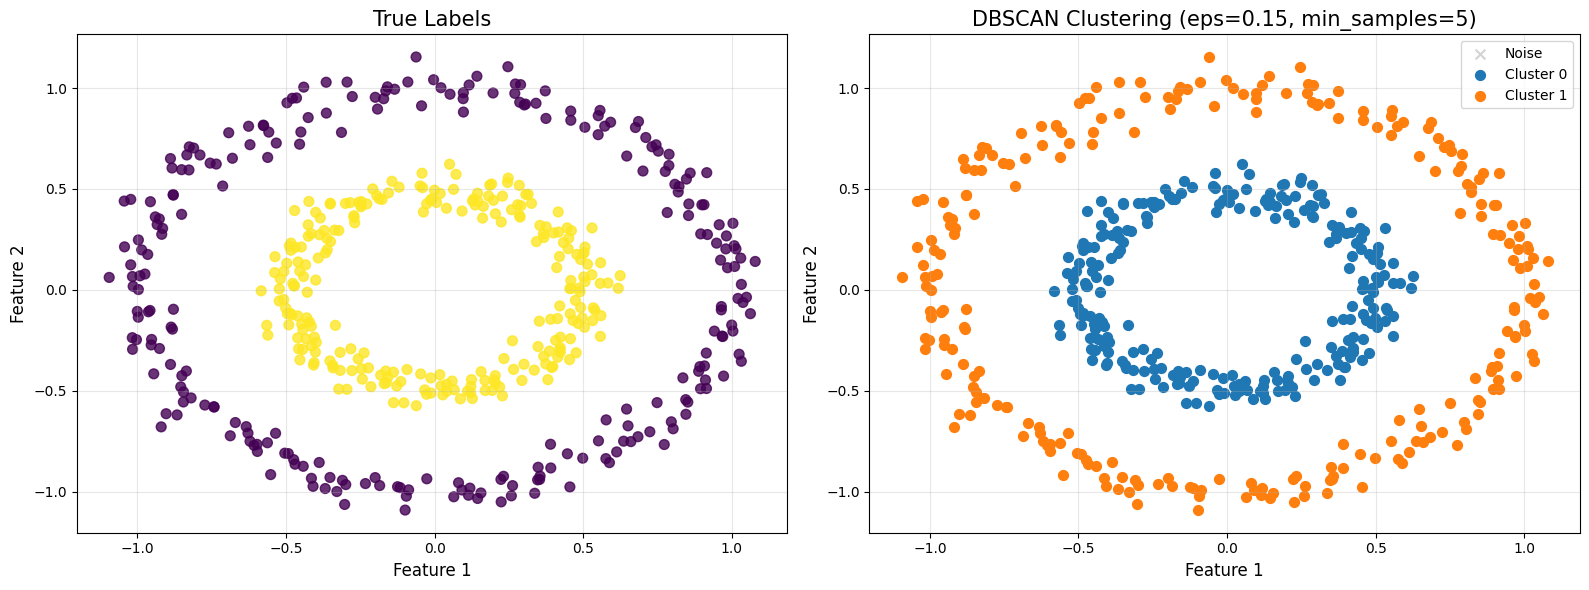

Dataset: Circles
Number of clusters: 2
Number of noise points: 0 (0.00%)
Silhouette Score: 0.1126 (higher is better)
Calinski-Harabasz Index: 0.0092 (higher is better)
Davies-Bouldin Index: 220.3932 (lower is better)


In [12]:
print("Evaluation for Circles Dataset:")
evaluate_dbscan_on_dataset(X_circles, y_circles, "Circles", eps=0.15, min_samples=5)

Evaluation for Moons Dataset:


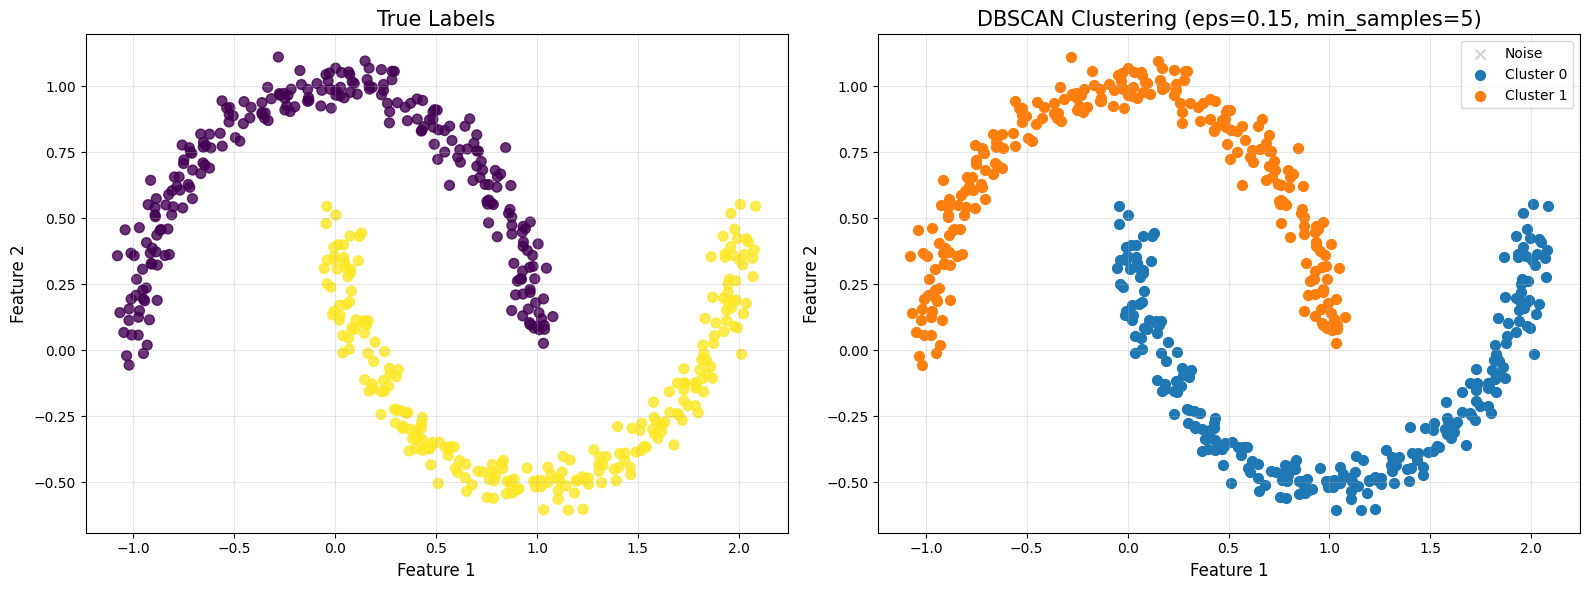

Dataset: Moons
Number of clusters: 2
Number of noise points: 0 (0.00%)
Silhouette Score: 0.3341 (higher is better)
Calinski-Harabasz Index: 332.4900 (higher is better)
Davies-Bouldin Index: 1.1518 (lower is better)


In [13]:
print("Evaluation for Moons Dataset:")
evaluate_dbscan_on_dataset(X_moons, y_moons, "Moons", eps=0.15, min_samples=5)

## 8. Conclusion and Key Takeaways

In this notebook, we've demonstrated the DBSCAN clustering algorithm and evaluated its performance using three different metrics:

1. **Silhouette Score**: Measures the quality of clusters by looking at how similar an object is to its own cluster compared to other clusters. Range: [-1, 1], higher is better.

2. **Calinski-Harabasz Index**: Measures the ratio of between-cluster dispersion to within-cluster dispersion. Higher values indicate better defined clusters.

3. **Davies-Bouldin Index**: Measures the average similarity between each cluster and its most similar cluster. Lower values indicate better clustering.

**Key takeaways:**

- DBSCAN doesn't require specifying the number of clusters in advance
- It can discover clusters of arbitrary shapes (not just spherical)
- It naturally handles outliers as noise points
- Finding appropriate eps and min_samples parameters is critical
- The k-distance graph can help identify a good eps value
- For complex shapes, DBSCAN often performs better than centroid-based methods like K-means
- Evaluation metrics can help validate the quality of the clustering

When applying clustering in real-world scenarios, it's important to:
1. Explore your data first
2. Try different clustering algorithms
3. Use multiple evaluation metrics
4. Consider domain knowledge when interpreting results